# UMI Correction Pipeline

**Module 00.5: Pearson Residuals for UMI Confounding Removal**

This module removes technical UMI (sequencing depth) confounding from gene expression using **Pearson residuals**, equivalent to SCTransform in Seurat.

**Why?** Standard log-normalization does not fully remove the correlation between expression levels and library size (UMI counts). This confounds downstream analyses — particularly senescence scoring, where cells with higher UMI depth can appear artifactually "more senescent."

**Method:** Analytic Pearson residuals model expected expression per gene using a negative binomial GLM with library size as covariate. The residuals represent expression *beyond what's expected given sequencing depth* — preserving biology while removing technical confounding.

**Input:** Module 00 preprocessed h5ad (log-normalized `.X` + raw counts)

**Output:** New h5ad with Pearson residuals in `.X`

**References:**
- Lause et al. (2021) *Genome Biology*. "Analytic Pearson residuals for normalization of single-cell RNA-seq UMI data"
- Hafemeister & Satija (2019) *Genome Biology*. "Normalization and variance stabilization of single-cell RNA-seq data using regularized negative binomial regression"

---
## Setup

Import libraries and verify scanpy version (requires >= 1.9 for Pearson residuals).

In [1]:
import scanpy as sc
import numpy as np
import scipy.sparse as sp
from scipy.stats import spearmanr
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

print(f"scanpy: {sc.__version__}")
print(f"numpy: {np.__version__}")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


scanpy: 1.11.5
numpy: 2.2.6


---
## Configuration

Set dataset name. All paths are derived automatically. Change `DATASET` to process different cohorts.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION (Change DATASET only)
# ══════════════════════════════════════════════════════════════════════════════

DATASET = 'psychad_aging'  # ← CHANGE THIS ONLY
# Options: 'psychad_aging', 'psychad_ad', 'psychencode'

BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
DATA_DIR = BASE_DIR / 'data' / 'processed'
FIGURES_DIR = BASE_DIR / 'figures' / '00_5_umi_correction' / DATASET
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = DATA_DIR / f'{DATASET}_preprocessed.h5ad'
OUTPUT_FILE = DATA_DIR / f'{DATASET}_pearson.h5ad'

# Pearson residuals parameters
CLIP_VALUE = 30  # Cap extreme residuals (standard practice, SCTransform v2)

print("="*80)
print(f"  Dataset:    {DATASET}")
print(f"  Input:      {INPUT_FILE}")
print(f"  Output:     {OUTPUT_FILE}")
print(f"  Clip value: ±{CLIP_VALUE}")
print(f"  Figures:    {FIGURES_DIR}")
print("="*80)

  Dataset:    psychad_aging
  Input:      /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_preprocessed.h5ad
  Output:     /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_pearson.h5ad
  Clip value: ±30
  Figures:    /fs/scratch/PAS2598/senescence_analysis/figures/00_5_umi_correction/psychad_aging


---
## Load Data

Load the preprocessed h5ad from Module 00 and verify structure.

**Expected:** `.X` = log-normalized, `layers['counts']` = raw integer counts.

In [3]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

start_time = time.time()
adata = sc.read_h5ad(INPUT_FILE)

print(f"\n  Loaded: {INPUT_FILE.name}")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Genes: {adata.n_vars:,}")
print(f"  .X dtype: {adata.X.dtype}")
print(f"  .X sparse: {sp.issparse(adata.X)}")
print(f"  Layers: {list(adata.layers.keys())}")

# Verify raw counts exist
if 'counts' not in adata.layers:
    raise ValueError("layers['counts'] not found! Module 00 must save raw counts.")

# Verify .X is log-normalized
if sp.issparse(adata.X):
    x_min = float(adata.X.data.min()) if len(adata.X.data) > 0 else 0
    x_max = float(adata.X.data.max()) if len(adata.X.data) > 0 else 0
else:
    x_min = float(np.min(adata.X))
    x_max = float(np.max(adata.X))

print(f"\n  .X range: [{x_min:.3f}, {x_max:.3f}]")
print(f"  (Expected: 0 to ~10 for log-normalized data)")

# Verify raw counts are integers
if sp.issparse(adata.layers['counts']):
    c_max = float(adata.layers['counts'].data.max()) if len(adata.layers['counts'].data) > 0 else 0
    sample_data = np.array(adata.layers['counts'].data[:1000])
else:
    c_max = float(np.max(adata.layers['counts']))
    sample_data = np.array(adata.layers['counts'].flat[:1000])

is_integer = np.allclose(sample_data, np.round(sample_data))
print(f"\n  layers['counts'] max: {c_max:.0f}")
print(f"  Contains integers: {is_integer}")

print(f"\n✓ Loaded in {time.time() - start_time:.1f}s")


LOADING DATA

  Loaded: psychad_aging_preprocessed.h5ad
  Cells: 553,621
  Genes: 34,890
  .X dtype: float32
  .X sparse: True
  Layers: ['counts']

  .X range: [0.050, 7.951]
  (Expected: 0 to ~10 for log-normalized data)

  layers['counts'] max: 8844
  Contains integers: True

✓ Loaded in 24.8s


---
## Pre-Correction UMI Confounding Check

Measure how strongly UMI depth (total counts) correlates with mean expression in the current log-normalized `.X`. A high Spearman ρ indicates UMI confounding that needs correction.

In [4]:
print("\n" + "="*80)
print("PRE-CORRECTION UMI CONFOUNDING CHECK")
print("="*80)

np.random.seed(42)
idx = np.random.choice(adata.n_obs, min(5000, adata.n_obs), replace=False)

X_sample = adata.X[idx]
if sp.issparse(X_sample):
    mean_expr_pre = np.asarray(X_sample.mean(axis=1)).flatten()
elif isinstance(X_sample, np.ndarray):
    mean_expr_pre = X_sample.mean(axis=1).flatten()
else:
    mean_expr_pre = np.asarray(X_sample).mean(axis=1).flatten()

total_counts = adata.obs['total_counts'].iloc[idx].values
rho_pre, pval_pre = spearmanr(mean_expr_pre, total_counts)

print(f"\n  Spearman ρ (mean .X vs total_counts): {rho_pre:.4f} (p={pval_pre:.2e})")

if abs(rho_pre) > 0.8:
    print(f"  ⚠ Strong UMI confounding (ρ={rho_pre:.2f})")
    print(f"    → Pearson residuals will correct this")
elif abs(rho_pre) > 0.5:
    print(f"  ~ Moderate UMI confounding (ρ={rho_pre:.2f})")
else:
    print(f"  ✓ Low UMI confounding (ρ={rho_pre:.2f})")

print(f"\n✓ Baseline recorded")


PRE-CORRECTION UMI CONFOUNDING CHECK

  Spearman ρ (mean .X vs total_counts): 0.9460 (p=0.00e+00)
  ⚠ Strong UMI confounding (ρ=0.95)
    → Pearson residuals will correct this

✓ Baseline recorded


---
## Prepare for Pearson Residuals

Store the current log-normalized expression as a layer (useful for visualization), then set `.X` to raw counts — the required input for Pearson residuals.

In [5]:
print("\n" + "="*80)
print("PREPARING FOR PEARSON RESIDUALS")
print("="*80)

# Save log-normalized as layer
print("\n  → Saving log-normalized .X to layers['lognorm']...")
adata.layers['lognorm'] = adata.X.copy()
print("    ✓ layers['lognorm'] stored")

# Set .X to raw counts
print("\n  → Setting .X = raw counts from layers['counts']...")
adata.X = adata.layers['counts'].copy()

# Clear log1p flag
if 'log1p' in adata.uns:
    del adata.uns['log1p']

print(f"\n  Data layers:")
print(f"    .X          → raw counts (input for Pearson residuals)")
print(f"    ['counts']  → raw counts (backup)")
print(f"    ['lognorm'] → log-normalized (for visualization)")

print(f"\n✓ Ready for Pearson residuals")


PREPARING FOR PEARSON RESIDUALS

  → Saving log-normalized .X to layers['lognorm']...
    ✓ layers['lognorm'] stored

  → Setting .X = raw counts from layers['counts']...

  Data layers:
    .X          → raw counts (input for Pearson residuals)
    ['counts']  → raw counts (backup)
    ['lognorm'] → log-normalized (for visualization)

✓ Ready for Pearson residuals


---
## Compute Pearson Residuals

Compute analytic Pearson residuals using a negative binomial GLM. For each gene:
```
residual = (observed - expected) / sqrt(variance)
```

Where `expected` and `variance` are modeled from the cell's library size. If a gene is highly expressed only because of deep sequencing, the residual ≈ 0. If expression exceeds what's expected given sequencing depth, the residual is large — that's biological signal.

Residuals are clipped to `±CLIP_VALUE` to prevent extreme outliers from rare/lowly expressed genes from dominating downstream analyses.

**⚠ This step is memory-intensive** (~75 GB for 550K cells × 35K genes).

In [6]:
print("\n" + "="*80)
print("COMPUTING PEARSON RESIDUALS")
print("="*80)

print(f"\n  Model:     Negative binomial GLM")
print(f"  Clipping:  ±{CLIP_VALUE}")
print(f"  Cells:     {adata.n_obs:,}")
print(f"  Genes:     {adata.n_vars:,}")

print("\n  → Computing Pearson residuals...")
start_time = time.time()

sc.experimental.pp.normalize_pearson_residuals(adata, clip=CLIP_VALUE)

elapsed = time.time() - start_time
print(f"\n  ✓ Computed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"    .X shape: {adata.X.shape}")
print(f"    .X dtype: {adata.X.dtype}")
print(f"    .X sparse: {sp.issparse(adata.X)}")


COMPUTING PEARSON RESIDUALS

  Model:     Negative binomial GLM
  Clipping:  ±30
  Cells:     553,621
  Genes:     34,890

  → Computing Pearson residuals...

  ✓ Computed in 350.2s (5.8 min)
    .X shape: (553621, 34890)
    .X dtype: float32
    .X sparse: False


---
## Post-Correction Verification

Verify that Pearson residuals effectively removed UMI confounding by comparing the Spearman ρ before and after correction, both at the overall level and per-gene level.

In [7]:
print("\n" + "="*80)
print("POST-CORRECTION VERIFICATION")
print("="*80)

# ── A. Overall correlation ────────────────────────────────────────────────────

print("\nA. OVERALL CORRELATION")
print(f"{'─'*60}")

X_sample = adata.X[idx]
if sp.issparse(X_sample):
    mean_expr_post = np.asarray(X_sample.mean(axis=1)).flatten()
elif isinstance(X_sample, np.ndarray):
    mean_expr_post = X_sample.mean(axis=1).flatten()
else:
    mean_expr_post = np.asarray(X_sample).mean(axis=1).flatten()

rho_post, pval_post = spearmanr(mean_expr_post, total_counts)

print(f"\n  {'Metric':<35} {'Before':>12} {'After':>12}")
print(f"  {'-'*61}")
print(f"  {'Spearman ρ (mean expr vs UMI)':<35} {rho_pre:>12.4f} {rho_post:>12.4f}")
print(f"  {'|ρ| improvement':<35} {'':>12} {abs(rho_pre) - abs(rho_post):>12.4f}")

# ── B. Value range ────────────────────────────────────────────────────────────

print(f"\nB. VALUE RANGE")
print(f"{'─'*60}")

if sp.issparse(adata.X):
    x_min = float(adata.X.data.min()) if len(adata.X.data) > 0 else 0
    x_max = float(adata.X.data.max()) if len(adata.X.data) > 0 else 0
else:
    x_min = float(np.min(adata.X))
    x_max = float(np.max(adata.X))

print(f"\n  .X range: [{x_min:.3f}, {x_max:.3f}]")
print(f"  Has negative values: {x_min < 0} (expected: True)")
print(f"  Clipped to ±{CLIP_VALUE}: {x_max <= CLIP_VALUE and x_min >= -CLIP_VALUE}")

# ── C. Per-gene correlation ───────────────────────────────────────────────────

print(f"\nC. PER-GENE CORRELATION (100 random genes)")
print(f"{'─'*60}")

np.random.seed(42)
gene_idx = np.random.choice(adata.n_vars, 100, replace=False)

rhos_pearson = []
rhos_lognorm = []

for g in gene_idx:
    if sp.issparse(adata.X):
        gene_expr = np.asarray(adata.X[:, g].todense()).flatten()
    else:
        gene_expr = adata.X[:, g].flatten()
    
    if sp.issparse(adata.layers['lognorm']):
        gene_ln = np.asarray(adata.layers['lognorm'][:, g].todense()).flatten()
    else:
        gene_ln = adata.layers['lognorm'][:, g].flatten()
    
    tc = adata.obs['total_counts'].values
    r1, _ = spearmanr(gene_expr, tc)
    r2, _ = spearmanr(gene_ln, tc)
    rhos_pearson.append(r1)
    rhos_lognorm.append(r2)

rhos_pearson = np.array(rhos_pearson)
rhos_lognorm = np.array(rhos_lognorm)

print(f"\n  {'Metric':<40} {'Log-norm':>10} {'Pearson':>10}")
print(f"  {'-'*62}")
print(f"  {'Mean |ρ| (gene vs UMI)':<40} {np.mean(np.abs(rhos_lognorm)):>10.4f} {np.mean(np.abs(rhos_pearson)):>10.4f}")
print(f"  {'Median |ρ| (gene vs UMI)':<40} {np.median(np.abs(rhos_lognorm)):>10.4f} {np.median(np.abs(rhos_pearson)):>10.4f}")
print(f"  {'Genes with |ρ| > 0.3':<40} {(np.abs(rhos_lognorm) > 0.3).sum():>10} {(np.abs(rhos_pearson) > 0.3).sum():>10}")
print(f"  {'Genes with |ρ| > 0.1':<40} {(np.abs(rhos_lognorm) > 0.1).sum():>10} {(np.abs(rhos_pearson) > 0.1).sum():>10}")

print(f"\n✓ Verification complete")


POST-CORRECTION VERIFICATION

A. OVERALL CORRELATION
────────────────────────────────────────────────────────────

  Metric                                    Before        After
  -------------------------------------------------------------
  Spearman ρ (mean expr vs UMI)             0.9460      -0.3438
  |ρ| improvement                                        0.6021

B. VALUE RANGE
────────────────────────────────────────────────────────────

  .X range: [-9.523, 30.000]
  Has negative values: True (expected: True)
  Clipped to ±30: True

C. PER-GENE CORRELATION (100 random genes)
────────────────────────────────────────────────────────────

  Metric                                     Log-norm    Pearson
  --------------------------------------------------------------
  Mean |ρ| (gene vs UMI)                       0.1487     0.7440
  Median |ρ| (gene vs UMI)                     0.1218     0.9021
  Genes with |ρ| > 0.3                              9         86
  Genes with |ρ| > 0.1

---
## Visualization

Side-by-side comparison of UMI correlation before (log-normalized) and after (Pearson residuals) correction.


VISUALIZATION


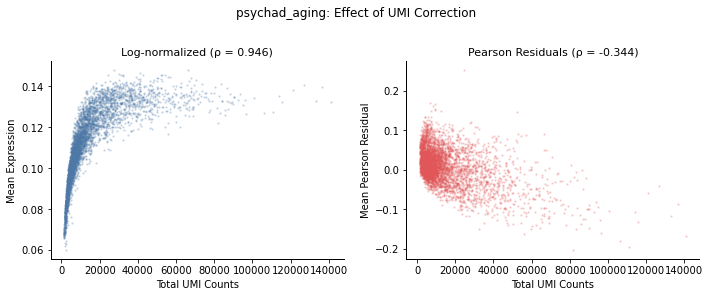

✓ Saved: psychad_aging_umi_correction_scatter.svg


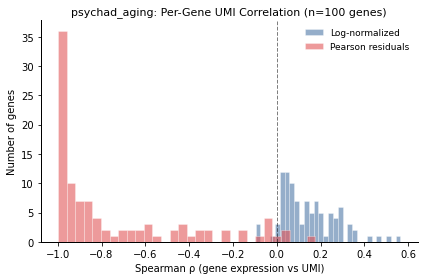

✓ Saved: psychad_aging_umi_correction_pergene.svg


In [8]:
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("VISUALIZATION")
print("="*80)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 10, 'axes.labelsize': 10,
    'axes.titlesize': 11, 'legend.fontsize': 9,
    'font.family': 'sans-serif', 'axes.linewidth': 1.0,
    'axes.grid': False, 'pdf.fonttype': 42,
})

# ── Before vs After scatter ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ln_sample = adata.layers['lognorm'][idx]
if sp.issparse(ln_sample):
    ln_mean = np.asarray(ln_sample.mean(axis=1)).flatten()
else:
    ln_mean = ln_sample.mean(axis=1).flatten()

axes[0].scatter(total_counts, ln_mean, s=2, alpha=0.2, c='#4E79A7', rasterized=True)
axes[0].set_xlabel('Total UMI Counts')
axes[0].set_ylabel('Mean Expression')
axes[0].set_title(f'Log-normalized (ρ = {rho_pre:.3f})')

axes[1].scatter(total_counts, mean_expr_post, s=2, alpha=0.2, c='#E15759', rasterized=True)
axes[1].set_xlabel('Total UMI Counts')
axes[1].set_ylabel('Mean Pearson Residual')
axes[1].set_title(f'Pearson Residuals (ρ = {rho_post:.3f})')

plt.suptitle(f'{DATASET}: Effect of UMI Correction', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_umi_correction_scatter.svg', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {DATASET}_umi_correction_scatter.svg")

# ── Per-gene rho distribution ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 4))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.hist(rhos_lognorm, bins=30, alpha=0.6, color='#4E79A7', label='Log-normalized', edgecolor='white', linewidth=0.5)
ax.hist(rhos_pearson, bins=30, alpha=0.6, color='#E15759', label='Pearson residuals', edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Spearman ρ (gene expression vs UMI)')
ax.set_ylabel('Number of genes')
ax.set_title(f'{DATASET}: Per-Gene UMI Correlation (n=100 genes)')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_umi_correction_pergene.svg', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {DATASET}_umi_correction_pergene.svg")

---
## Save Results

Save the UMI-corrected dataset with all three expression representations.

**Final data structure:**
- `.X` → Pearson residuals (UMI-corrected, for SenePy scoring)
- `layers['counts']` → raw counts (for DEG analysis)
- `layers['lognorm']` → log-normalized (for visualization)

In [9]:
print("\n" + "="*80)
print("SAVING")
print("="*80)

print(f"\n  Final data structure:")
print(f"    Cells: {adata.n_obs:,}")
print(f"    Genes: {adata.n_vars:,}")
print(f"    .X:              Pearson residuals (UMI-corrected)")
print(f"    layers['counts']: raw counts (untouched)")
print(f"    layers['lognorm']: log-normalized expression")

OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
print(f"\n  Saving to: {OUTPUT_FILE}")

start_time = time.time()
adata.write_h5ad(OUTPUT_FILE)
elapsed = time.time() - start_time

file_size = OUTPUT_FILE.stat().st_size / 1e9
print(f"\n✓ Saved in {elapsed:.1f}s ({file_size:.2f} GB)")


SAVING

  Final data structure:
    Cells: 553,621
    Genes: 34,890
    .X:              Pearson residuals (UMI-corrected)
    layers['counts']: raw counts (untouched)
    layers['lognorm']: log-normalized expression

  Saving to: /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_pearson.h5ad

✓ Saved in 44.7s (132.04 GB)


---
## Summary

UMI correction complete. Data ready for Module 01: Senescence Scoring.

In [10]:
print("\n" + "="*80)
print("✓ MODULE 00.5 COMPLETE: UMI CORRECTION")
print("="*80)

print(f"""
  Dataset: {DATASET}

  Final dimensions:
    Cells: {adata.n_obs:,}
    Genes: {adata.n_vars:,}

  Data structure:
    adata.X:              Pearson residuals (UMI-corrected)
    adata.layers['counts']: raw counts
    adata.layers['lognorm']: log-normalized expression

  UMI correction:
    Before (log-norm):    ρ = {rho_pre:.4f}
    After (Pearson):      ρ = {rho_post:.4f}
    Clip value:           ±{CLIP_VALUE}

  Output files:
    Data:    {OUTPUT_FILE}
    Figures: {FIGURES_DIR}/

  → Ready for Module 01: Senescence Scoring
""")


✓ MODULE 00.5 COMPLETE: UMI CORRECTION

  Dataset: psychad_aging

  Final dimensions:
    Cells: 553,621
    Genes: 34,890

  Data structure:
    adata.X:              Pearson residuals (UMI-corrected)
    adata.layers['counts']: raw counts
    adata.layers['lognorm']: log-normalized expression

  UMI correction:
    Before (log-norm):    ρ = 0.9460
    After (Pearson):      ρ = -0.3438
    Clip value:           ±30

  Output files:
    Data:    /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_pearson.h5ad
    Figures: /fs/scratch/PAS2598/senescence_analysis/figures/00_5_umi_correction/psychad_aging/

  → Ready for Module 01: Senescence Scoring

